# Ejercicio 8.3 — Comparación de distribuciones

Se comparan distribuciones del proxy de cianobacteria mediante histogramas, boxplots, estadísticas robustas y mapas de diferencia. Las fechas se eligen mediante reglas declaradas antes de graficar: primera fecha completa, pico de promedio temporal, mayor extensión espacial y fecha común entre lagos.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.correlaciones import validate_inputs, run_distributions

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 170)

## 1. Ejecución y selección auditable de fechas

In [2]:
validation = validate_inputs()
results = run_distributions()
validation, results["selections"]

({'filas_manifest': 66, 'rasters': 66, 'escenas': 22},
 {'atitlan': {'2025-04-13': 'referencia_primera_fecha_completa',
   '2026-04-13': 'fecha_comun_entre_lagos;pico_promedio_temporal',
   '2026-07-22': 'mayor_extension'},
  'amatitlan': {'2025-01-28': 'referencia_primera_fecha_completa',
   '2026-04-13': 'fecha_comun_entre_lagos',
   '2026-06-19': 'mayor_extension;pico_promedio_temporal'}})

## 2. Estadísticas de las fechas seleccionadas

In [3]:
table = pd.DataFrame(results["table"])
table.loc[table["criterio_seleccion"] != "", [
    "lago", "fecha", "criterio_seleccion", "n_pixeles", "media", "mediana",
    "q25", "q75", "p95", "quality_flag"
]]

,lago,fecha,criterio_seleccion,n_pixeles,media,mediana,q25,q75,p95,quality_flag
0,amatitlan,2025-01-28,referencia_primera_fecha_completa,143791,4.433330,4.489381,4.276954,4.633588,4.802200,calculado
8,amatitlan,2026-04-13,fecha_comun_entre_lagos,140873,6.783518,6.440962,5.766152,7.235643,9.752563,calculado
10,amatitlan,2026-06-19,mayor_extension;pico_promedio_temporal,141050,11.316754,10.730481,6.266788,14.541948,21.344893,calculado
12,atitlan,2025-04-13,referencia_primera_fecha_completa,1218498,1.781121,1.750455,1.387262,2.144897,2.821827,calculado
19,atitlan,2026-04-13,fecha_comun_entre_lagos;pico_promedio_temporal,1216030,2.125347,2.198721,1.640296,2.720939,3.342323,calculado
21,atitlan,2026-07-22,mayor_extension,1212296,1.124734,1.118861,0.393963,1.893645,2.827377,revisar_valores_atipicos


## 3. Histogramas y boxplots con límites comunes

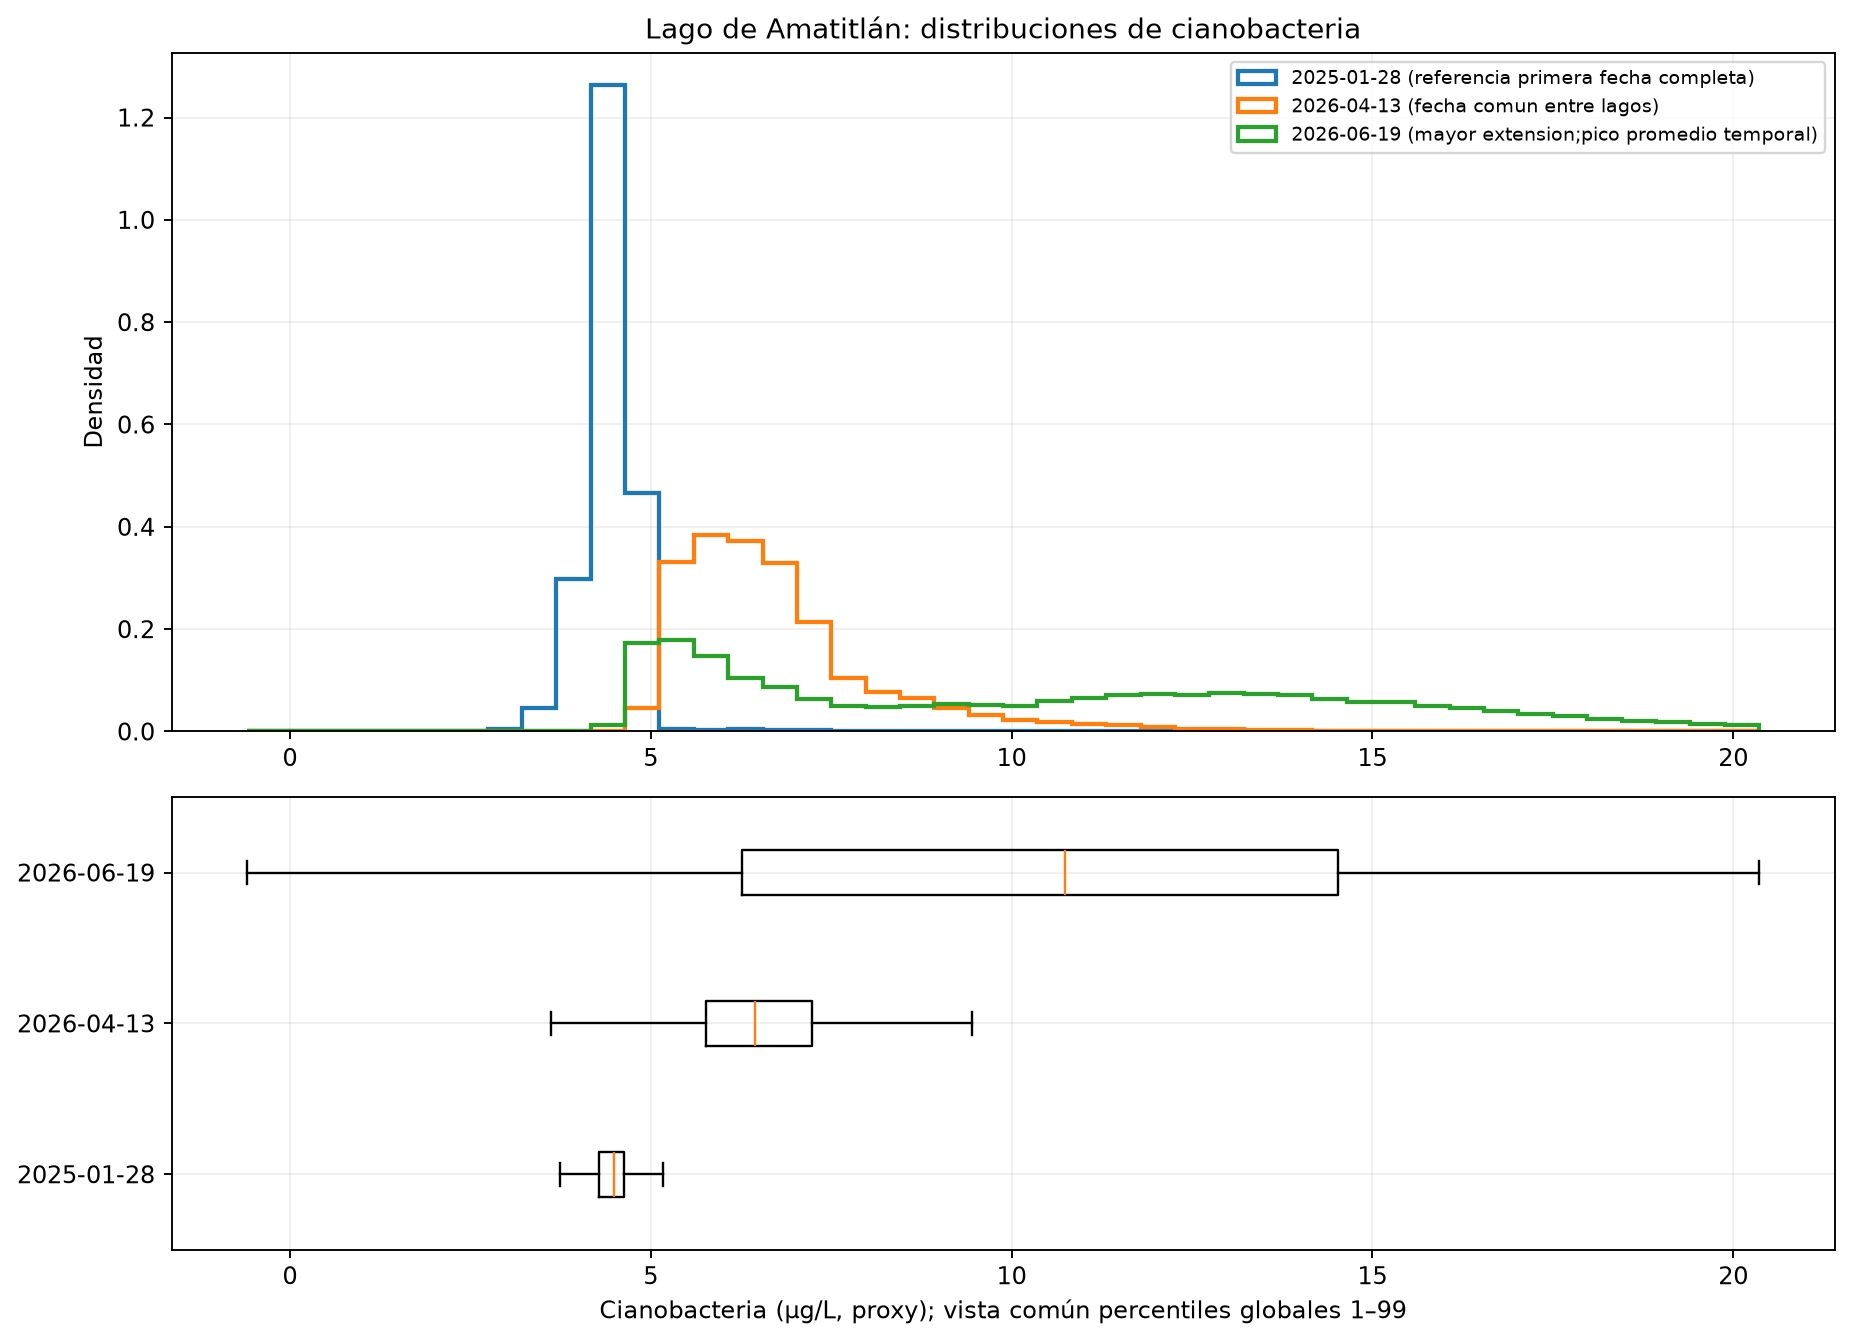

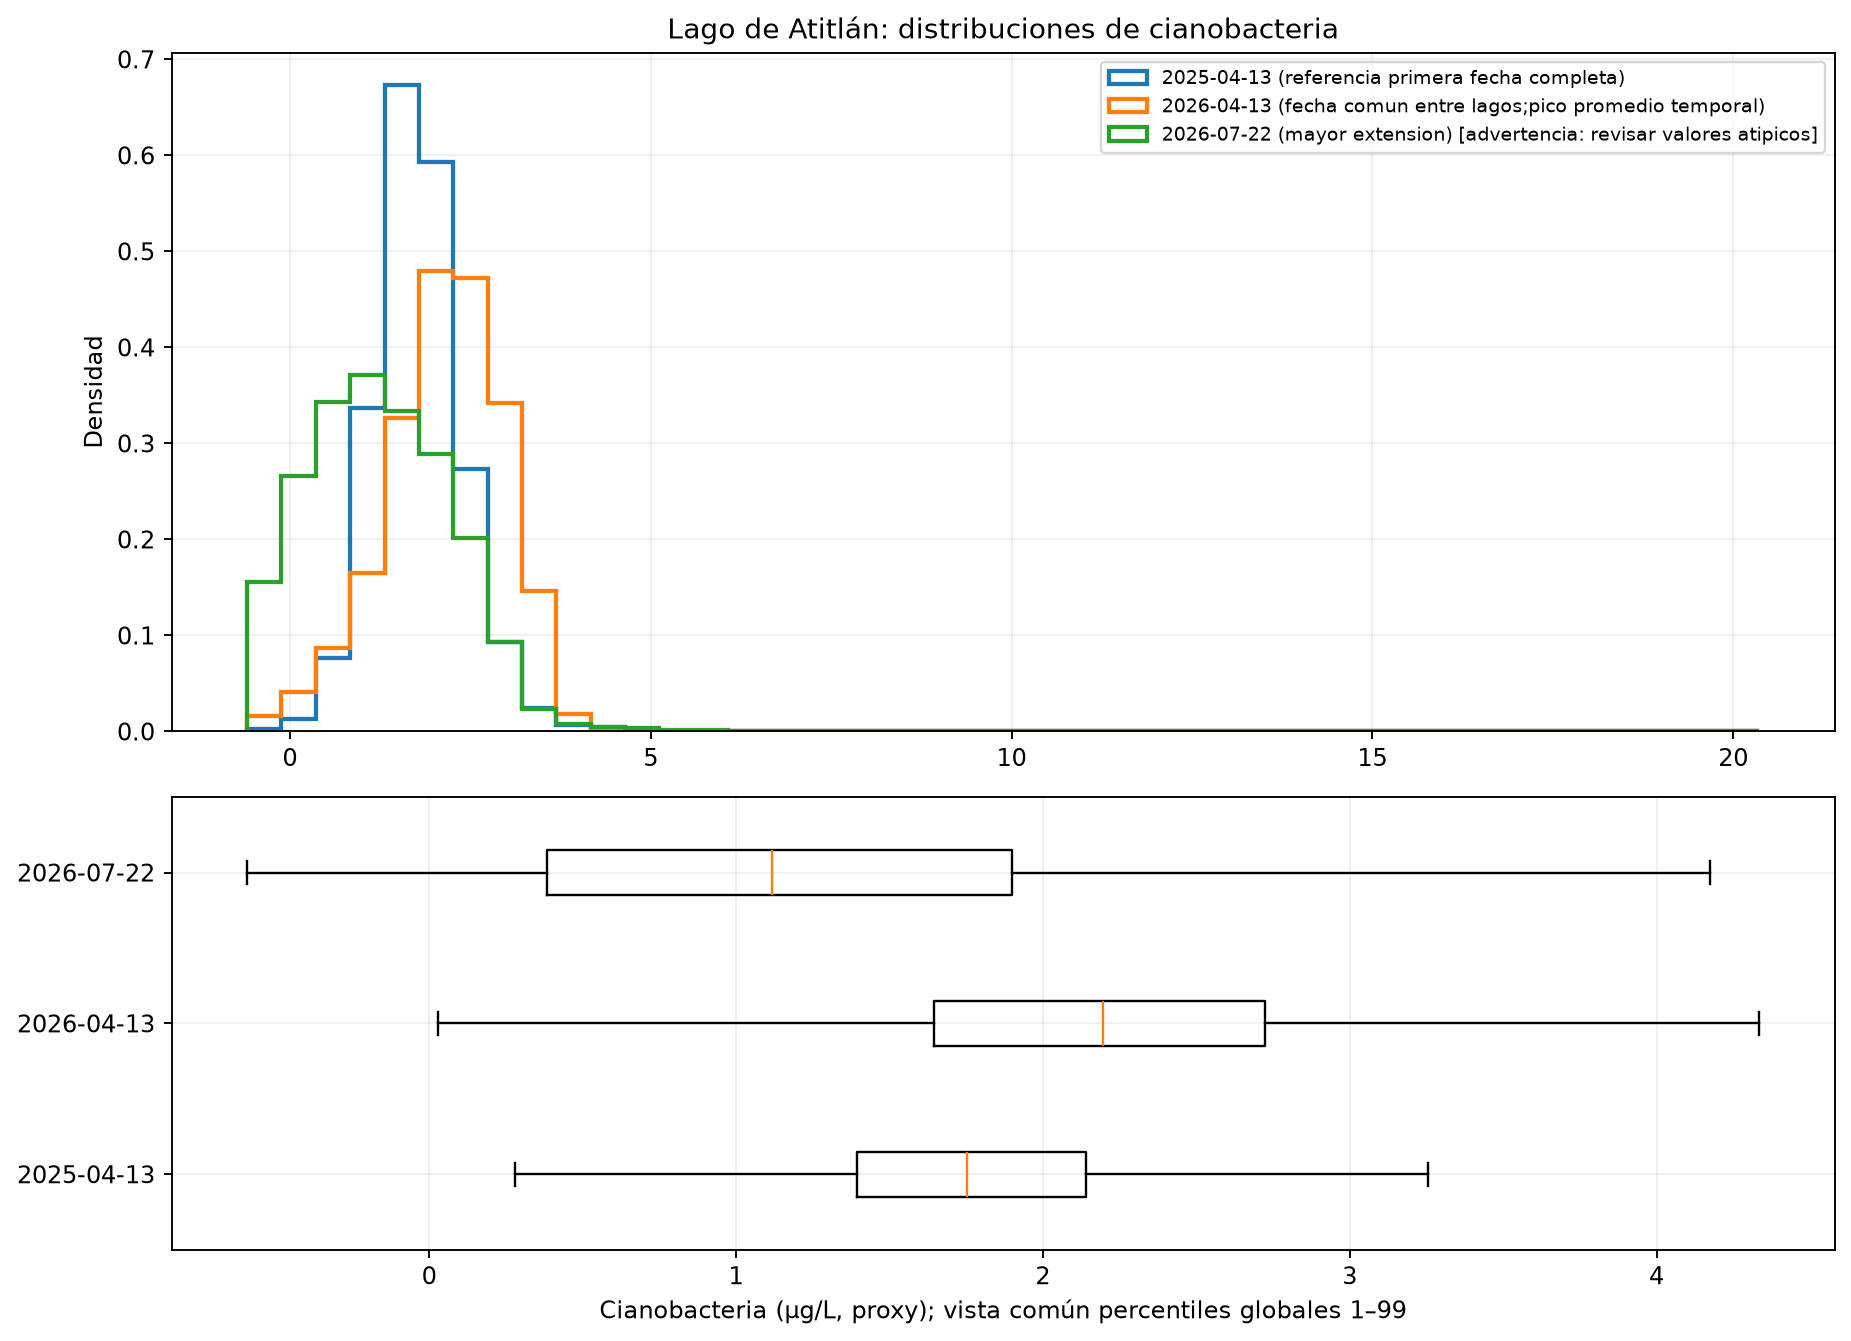

In [4]:
for lake in ("amatitlan", "atitlan"):
    display(Image(filename=str(ROOT / f"results/figures/{lake}_distribuciones_cianobacteria.png")))

## 4. Diferencia espacial: fecha final menos fecha inicial

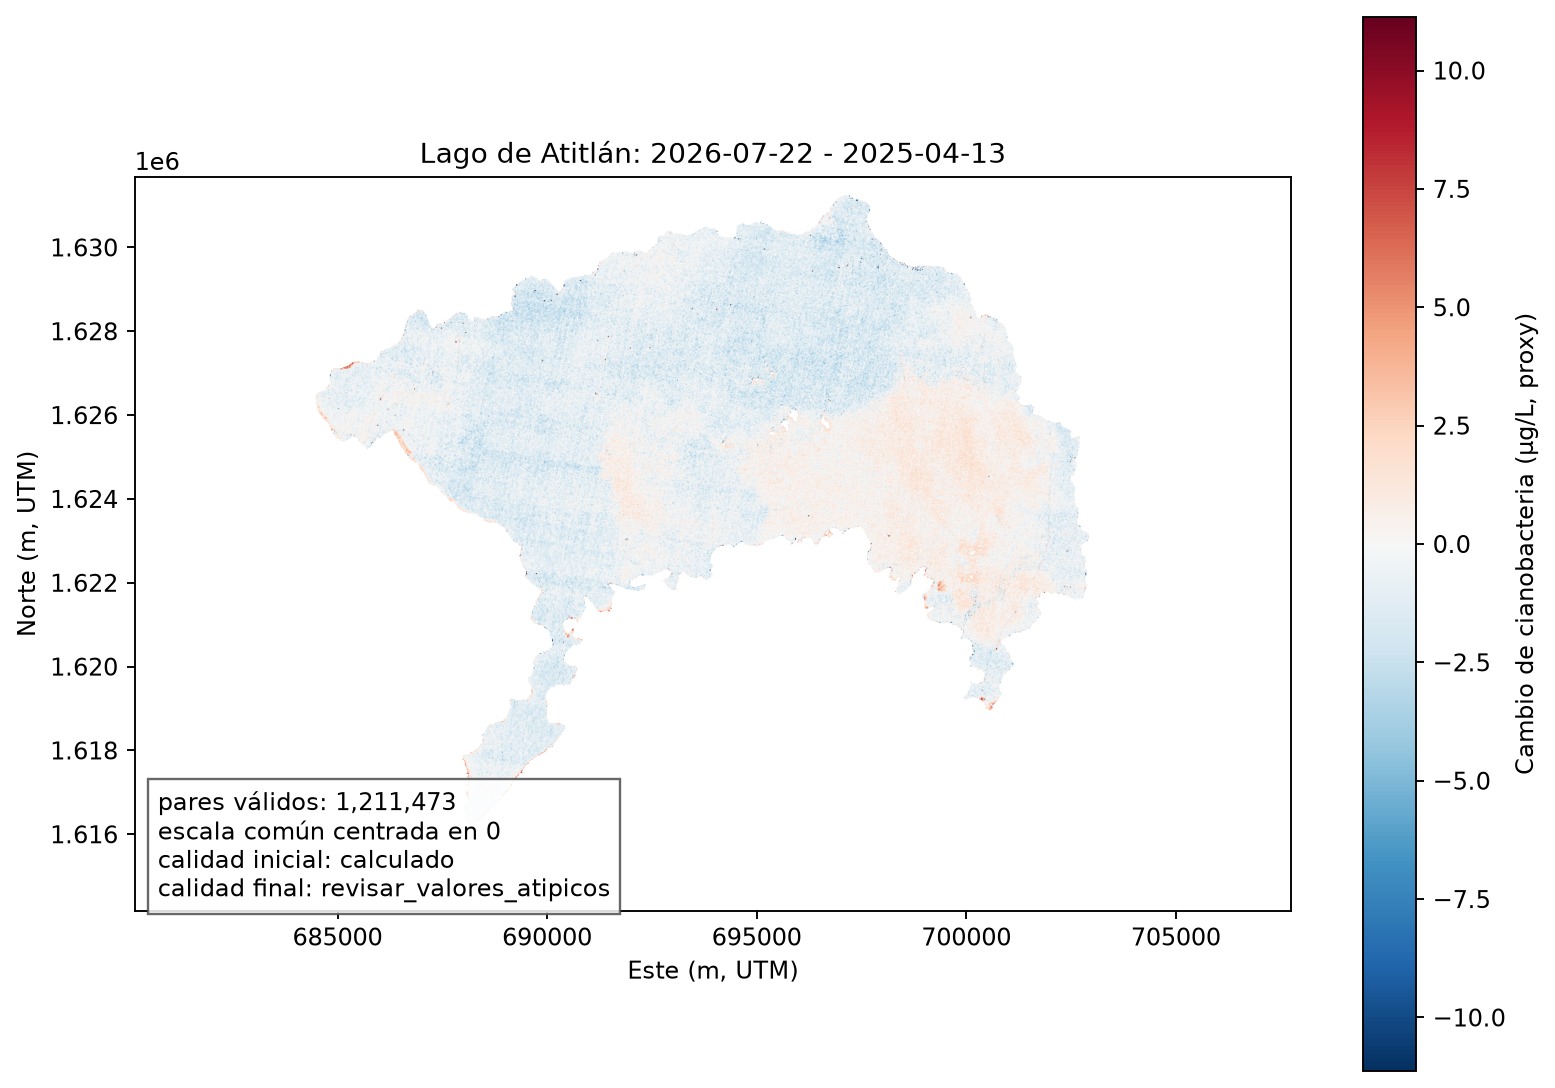

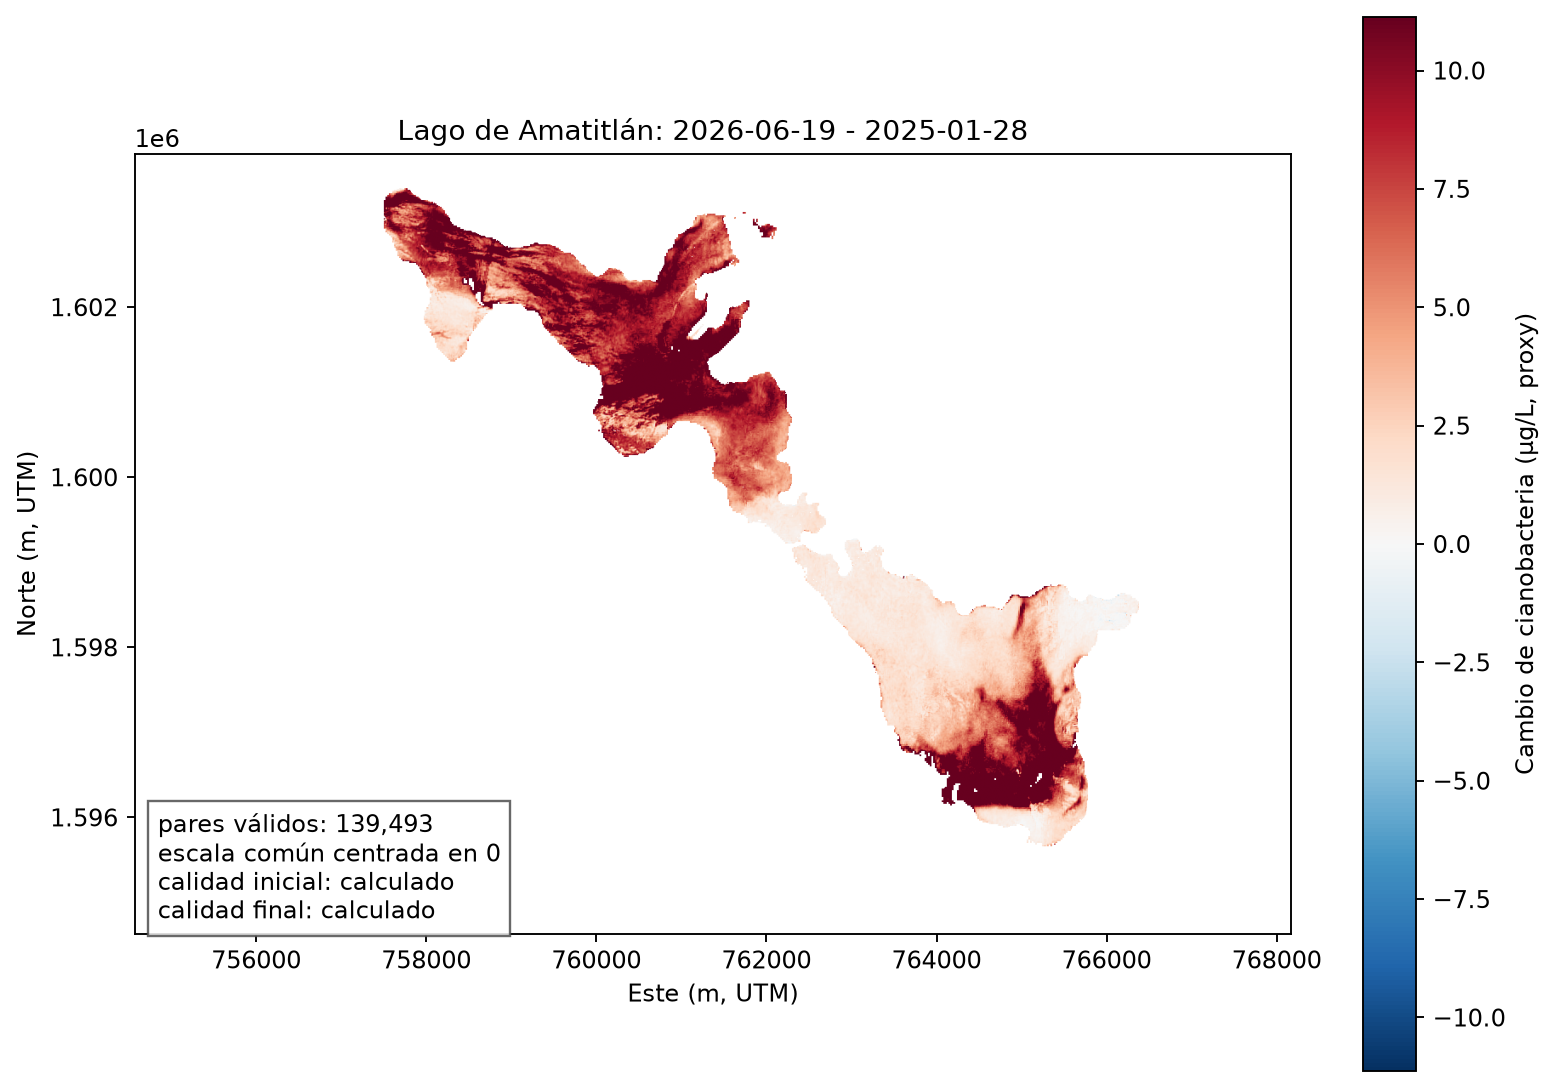

In [5]:
for path in results["maps"]:
    display(Image(filename=str(path)))

## 5. Hallazgos

- **Amatitlán:** la distribución se desplaza de una mediana de aproximadamente 4.49 µg/L en la referencia (2025-01-28) a 6.44 µg/L en la fecha común (2026-04-13) y 10.73 µg/L en la fecha de mayor extensión/pico (2026-06-19). El percentil 95 llega a ≈ 21.34 µg/L. El boxplot muestra que no sube únicamente el promedio: aumenta el centro y también se ensancha la distribución. El mapa `2026-06-19 - 2025-01-28` muestra incrementos extensos, aunque con intensidad espacial heterogénea.
- **Atitlán:** las tres distribuciones seleccionadas permanecen mucho más bajas. La fecha común/pico tiene mediana ≈ 2.20 µg/L, mientras la fecha de mayor extensión (2026-07-22) tiene mediana ≈ 1.12 µg/L y está marcada `revisar_valores_atipicos`. Su mapa de diferencia es mixto y de magnitud pequeña comparado con Amatitlán; no sustenta una floración extendida comparable.

El promedio por sí solo ocultaría estas diferencias: Amatitlán combina desplazamiento del centro, mayor dispersión y una cola superior amplia; Atitlán conserva valores bajos con cambios localizados y una fecha final que requiere cautela.

## Limitaciones

- Los límites visuales corresponden a los percentiles globales 1–99 de las fechas seleccionadas; la tabla conserva mínimos, máximos y percentiles completos.
- Los mapas solo restan rasters con CRS, transformación, dimensiones y resolución idénticos, y usan píxeles válidos en ambas fechas.
- Los valores son un proxy satelital de clorofila-a asociada a cianobacterias, no una medición directa de toxinas.
- La fecha `2026-07-22` de Atitlán conserva explícitamente su advertencia de valores atípicos.

## Productos

- `results/tables/distribuciones_por_fecha.csv`
- dos figuras de histogramas/boxplots en `results/figures/`
- dos mapas de diferencia en `results/maps/`